In [7]:
from qutip import *
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib
import sys
from pathlib import Path
import json
from lmfit import Model
from matplotlib.ticker import MaxNLocator


import scienceplots as splt
matplotlib.pyplot.style.use(['science', 'notebook', 'ieee'])
matplotlib.pyplot.rcParams['font.family'] = 'Times New Roman'


# Aggiunge src alla path dei moduli
project_root = Path.cwd().parent.parent 
sys.path.append(str(project_root / "src"))


from molecules.molecule import CaH, CaOH, CaOH_dm2, CaH_dm2

from pumping.pump_evolution import run_pumping
from QLS.state_dist import States
from RAP.rap_utils import *
from RAP.rap_evolution import *
from saving import save_rap_signature

# Molecule creation

In [2]:
b_field_gauss = 3.6
j_max = 14

mo1 = CaH.create_molecule_data(b_field_gauss=b_field_gauss, j_max=j_max)

temperature = 300
states1 = States(mo1, temperature)

molecule_type = "CaH"

Saved molecule data in:
/home/stripzio/bayesian-qls/re_project/molecule_data/CaH_B[3.60]_Jmax[14]_states.csv
/home/stripzio/bayesian-qls/re_project/molecule_data/CaH_B[3.60]_Jmax[14]_transitions.csv


In [3]:
left_to_left, left_to_right, signature_trans_left, signature_trans_right = compute_transitions(mo1, j_max)

# Pulse creation

In [4]:
n_motional = 2
trap_freq = 2*np.pi*1000    # kHz
is_minus = True
rabi_rate = 2*np.pi*0.05

D = 2*np.pi*0.1        # kHz
T = 50000
sigma = T/7

time_steps_mol = 1000
final_time = T   # us           
times = np.linspace(0, final_time, time_steps_mol)


laser_detuning = 2 * np.pi * - 0.13      # kHz

from_simulation = False
dm = -1
init_pop_list = [1.00, 0.00]

/home/stripzio/.local/lib/python3.10/site-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(
/home/stripzio/.local/lib/python3.10/site-packages/qutip/solver/solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


RAP of the transition in j =  0
Density Matrix created
BSB Hamiltonian created; now simulating
Hamiltonian created; now simulating
Final state saved in: /home/stripzio/bayesian-qls/re_project/results_rap_cah/RAP_J0_B3.60G_T50.00ms_SIGMA7.14ms_0.1000_RR50.0000_DET-130.0000_DM-1_fromsimFalse.pkl_0.pkl
RAP of the transition in j =  1
Density Matrix created
BSB Hamiltonian created; now simulating
Hamiltonian created; now simulating
Final state saved in: /home/stripzio/bayesian-qls/re_project/results_rap_cah/RAP_J1_B3.60G_T50.00ms_SIGMA7.14ms_0.1000_RR50.0000_DET-130.0000_DM-1_fromsimFalse.pkl_0.pkl
RAP of the transition in j =  2
Density Matrix created
BSB Hamiltonian created; now simulating
Hamiltonian created; now simulating
Final state saved in: /home/stripzio/bayesian-qls/re_project/results_rap_cah/RAP_J2_B3.60G_T50.00ms_SIGMA7.14ms_0.1000_RR50.0000_DET-130.0000_DM-1_fromsimFalse.pkl_0.pkl
RAP of the transition in j =  3
Density Matrix created
BSB Hamiltonian created; now simulating
Ha

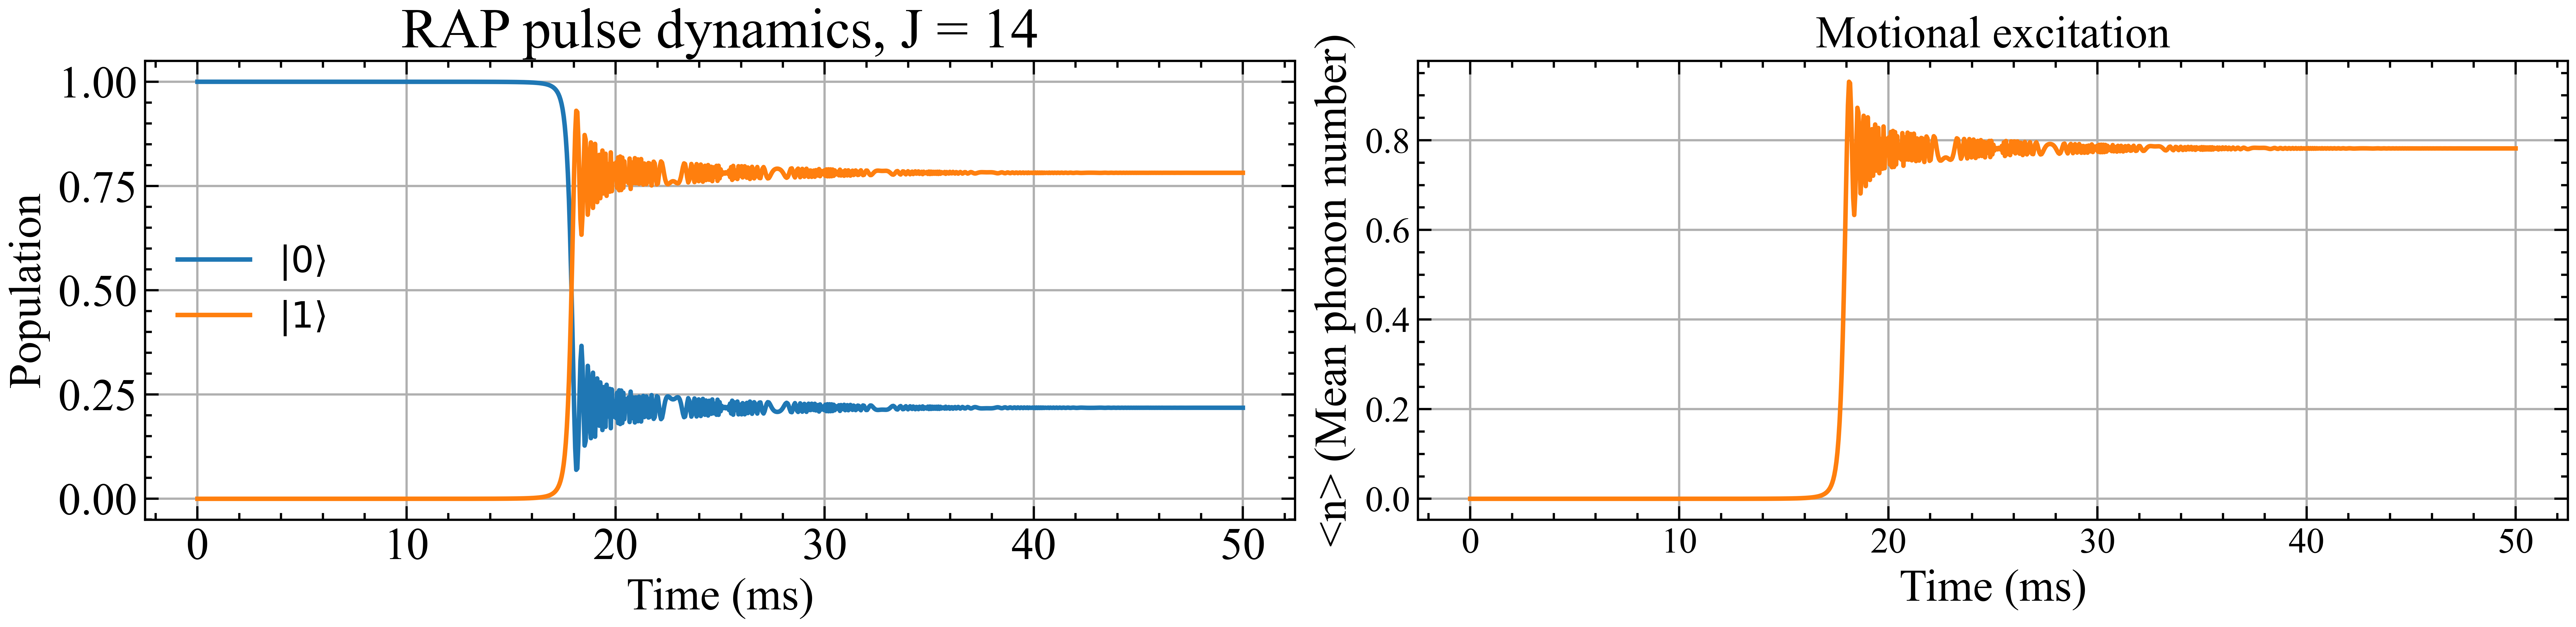

In [5]:
j_plot = 14


full_paths_list, args, list_up_sign_high = RAP_simulation(signature_trans_left, n_motional, b_field_gauss, rabi_rate, laser_detuning, is_minus, times, 
                                       T, D, sigma, 
                                       trap_freq = trap_freq, lamb_dicke=None, from_simulation = from_simulation, dm = dm, rabi_flop=False, sideband = True, off_resonant = False, init_pop_list = init_pop_list,
                                       j_plot = j_plot, savetext = "cah", molecule_type = molecule_type)


Saved figure in: /home/stripzio/bayesian-qls/re_project/images/cah_j14.svg


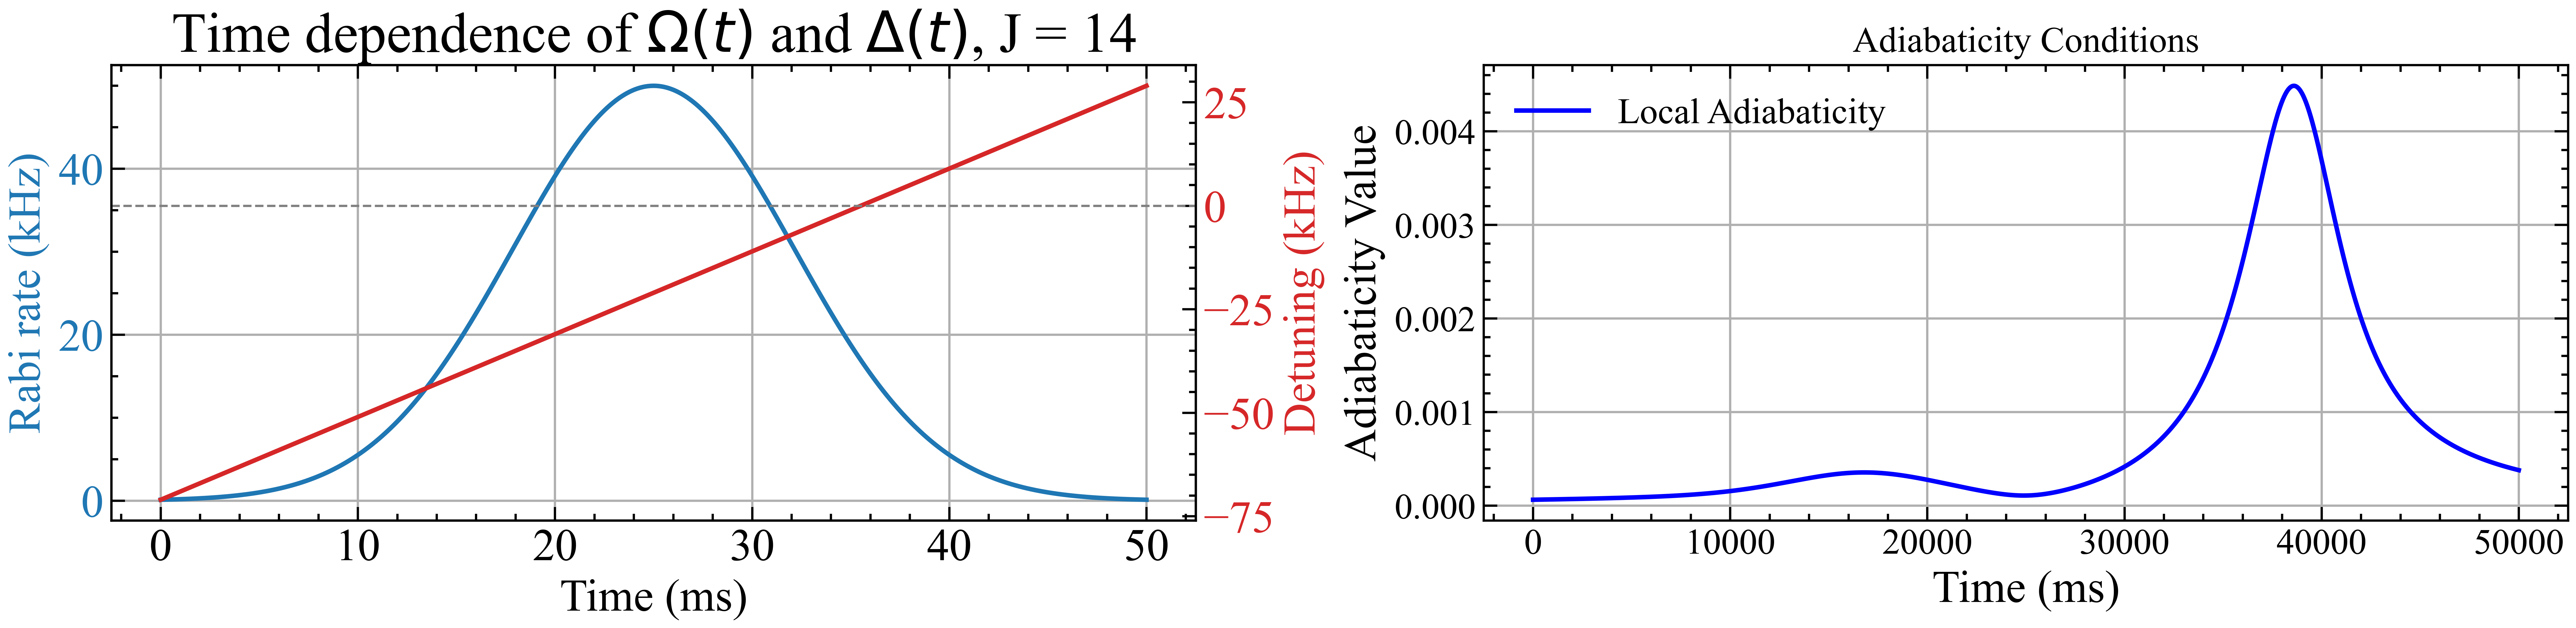

In [6]:
chirp_envelope(args, times, T, D, sigma, rabi_rate, laser_detuning, j_plot = j_plot, savetext="cah")

In [8]:
j_vals = sorted(list_up_sign_high.keys())
pop_vals = [list_up_sign_high[j] for j in j_vals]


save_rap_signature(j_vals, pop_vals, filename = "rap_signature_cah.pkl", molecule_type = "cah")



RAP signature saved in: /home/stripzio/bayesian-qls/re_project/pumping_RAP_data_cah/rap_signature_cah.pkl


'/home/stripzio/bayesian-qls/re_project/pumping_RAP_data_cah/rap_signature_cah.pkl'